## **MTN Nigeria Customer Churn Prediction Project**

**Objective**  
Transform the cleaned customer-level dataset into a high-quality, modeling-ready feature set that preserves the strongest signals identified in EDA while adding a small number of high-value, interpretable engineered features.

**Business Context**  
We want to identify customers at high risk of churning so MTN Nigeria can proactively offer targeted retention interventions (better data bundles, loyalty discounts, network quality improvements in high-churn regions, etc.) → directly protecting revenue in a highly competitive telecom market.

**Goal**  
Build and evaluate several baseline classification models using the engineered features from `03_feature_engineering.ipynb`.  

**Business Objective Reminder**  
Accurately predict customers likely to churn so MTN can target retention offers (better bundles, loyalty discounts, network fixes in hotspot states) and reduce revenue loss in Nigeria’s competitive telecom market.

**Success Criteria**  
- Strong baseline performance (aim for PR-AUC > 0.45 and good Recall on the positive class)  
- Clear feature importance insights that align with EDA findings  
- Reproducible pipeline with saved models and artifacts

**Import & Configuration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    average_precision_score, precision_recall_curve, roc_curve
)

pd.set_option("display.max_columns", 100)
%matplotlib inline
sns.set(style="whitegrid")

**Load Engineering Dataset**

In [2]:
df = pd.read_csv(r"C:\Users\KOLADE\OneDrive\Documents\AkoladeDSJourney\MTN-Nigeria-Customer-Churn\data\processed\03_engineered_for_modeling.csv")

print("Shape:", df.shape)
print("Churn rate:", df["Churn"].mean().round(3))
print("\nColumns:", df.columns.tolist())

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Features: {X.shape[1]}")

Shape: (496, 31)
Churn rate: 0.294

Columns: ['Customer_Tenure_Months', 'Total_Revenue', 'Avg_Satisfaction_Rate', 'Usage_vs_Purchased_Ratio', 'Avg_Data_Usage_GB', 'Churn', 'log_Total_Revenue', 'log_Usage_vs_Purchased_Ratio', 'winsor_Usage_Ratio', 'Primary_Plan_Type_2-Day', 'Primary_Plan_Type_3-Month', 'Primary_Plan_Type_Daily', 'Primary_Plan_Type_Monthly', 'Primary_Plan_Type_Yearly', 'State_Group_High_Churn_State', 'State_Group_Low_Churn_State', 'State_Group_Medium_Churn_State', 'Primary_Review_Excellent', 'Primary_Review_Fair', 'Primary_Review_Good', 'Primary_Review_Poor', 'Primary_Review_Very Good', 'Region_North Central', 'Region_North East', 'Region_North West', 'Region_South East', 'Region_South South', 'Region_South West', 'short_tenure_high_usage_flag', 'high_value_customer', 'short_cycle_plan_flag']
Features: 30


**Train-Test Split (Stratified)**  
The `stratify` parameter ensures that the train and test sets preserve the exact same percentage of samples for each class as the original dataset.

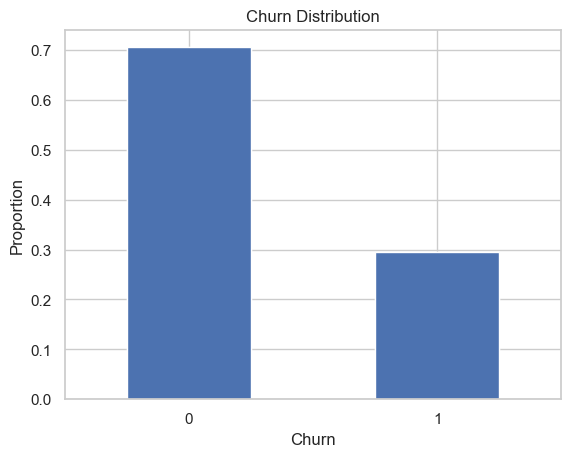

In [5]:
df["Churn"].value_counts(normalize=True).plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Churn rate - Train:", y_train.mean().round(3))
print("Churn rate - Test: ", y_test.mean().round(3))

Train shape: (372, 30)
Test shape:  (124, 30)
Churn rate - Train: 0.296
Churn rate - Test:  0.29


**Baseline Models**  
- Logistics Regressions (interpretable baseline)
- Random Forest (strong non-linear baseline)
- XGBoost (usually the strongest tree-based model)

In [7]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=5,
        random_state=42,
        eval_metric='aucpr'
    )
}

results = {}

**Training & Evaluation Function**

In [8]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    # Fit
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    print(f"\n=== {name} ===")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return {
        "model": model,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "y_proba": y_proba
    }


=== LogisticRegression ===
ROC-AUC:  0.5540
PR-AUC:   0.3366

Classification Report:
              precision    recall  f1-score   support

           0     0.7103    0.8636    0.7795        88
           1     0.2941    0.1389    0.1887        36

    accuracy                         0.6532       124
   macro avg     0.5022    0.5013    0.4841       124
weighted avg     0.5895    0.6532    0.6080       124



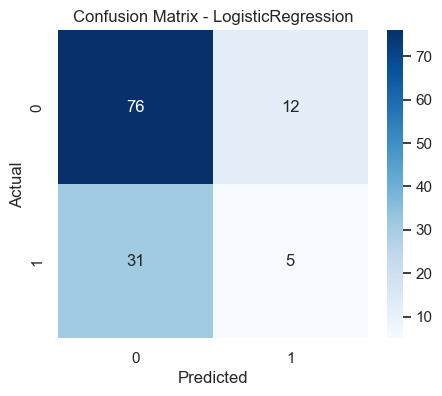


=== RandomForest ===
ROC-AUC:  0.5587
PR-AUC:   0.3576

Classification Report:
              precision    recall  f1-score   support

           0     0.7196    0.8750    0.7897        88
           1     0.3529    0.1667    0.2264        36

    accuracy                         0.6694       124
   macro avg     0.5363    0.5208    0.5081       124
weighted avg     0.6132    0.6694    0.6262       124



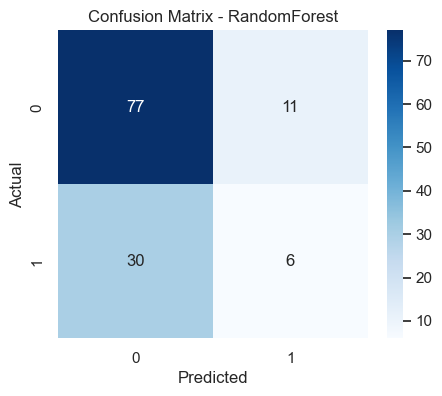


=== XGBoost ===
ROC-AUC:  0.5846
PR-AUC:   0.3613

Classification Report:
              precision    recall  f1-score   support

           0     0.7374    0.8295    0.7807        88
           1     0.4000    0.2778    0.3279        36

    accuracy                         0.6694       124
   macro avg     0.5687    0.5537    0.5543       124
weighted avg     0.6394    0.6694    0.6493       124



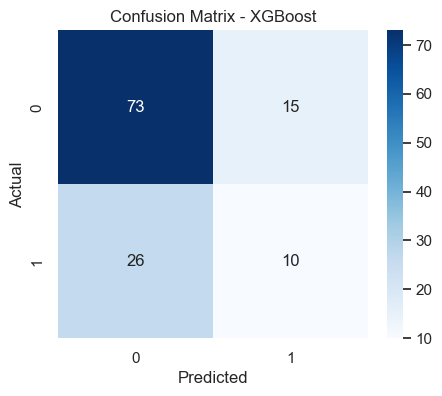

In [9]:
# Run evaluation for each model
for name, model in models.items():
    results[name] = evaluate_model(name, model, X_train, y_train, X_test, y_test)

### Summary

**Key Takeaways:**

- XGBoost is the strongest baseline (as expected), but all models struggle with the positive class (churners) — very low recall.
- This is common in churn problems with moderate imbalance (~30% churn) and subtle signals.
- The models are biased toward predicting "No Churn" → not ideal for business (we want to catch as many churners as possible for retention campaigns).
- Feature engineering helped a bit, but we need class imbalance handling, hyperparameter tuning, and possibly threshold optimization.

**Business Implication:**
With current recall ~0.28, we would only identify about 1 in 4 churners — missing significant revenue protection opportunity. We can improve this substantially.